# Notebook 05: Stage 2 - FairDrift Framework

Implements and calibrates the complete FairDrift monitoring pipeline:
- Component A: Subgroup-level drift detection (KS/ADWIN/PH ensemble)
- Component B: CUSUM sequential fairness testing
- Component C: Interpretable alert generation


In [1]:
import sys, os, pickle
if 'google.colab' in sys.modules:
    sys.path.insert(0, '/content/FairDrift-code')
else:
    sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.drift_detectors import DriftEnsemble, run_subgroup_drift_detection
from src.cusum import CUSUMChart, FairnessCUSUMMonitor
from src.fairness_metrics import compute_all_fairness_metrics

with open('../outputs/checkpoint_01.pkl', 'rb') as f:
    ckpt01 = pickle.load(f)
with open('../outputs/checkpoint_02.pkl', 'rb') as f:
    ckpt02 = pickle.load(f)

windows = ckpt01['windows']
feature_cols = ckpt01['feature_cols']
models = ckpt02['models']
scaler = ckpt02['scaler']
print('Loaded checkpoints')


Loaded checkpoints


## 1. Component A: Subgroup Drift Detection

In [2]:
# Run drift detection for race subgroups
key_features = ['num_medications', 'num_lab_procedures', 'number_diagnoses',
                'time_in_hospital', 'number_inpatient', 'number_emergency', 'num_procedures']
# Filter to features that exist after preprocessing
key_features = [f for f in key_features if f in feature_cols]

drift_results = run_subgroup_drift_detection(
    windows, key_features, 'race', ['Caucasian', 'AfricanAmerican', 'Hispanic']
)

print('SUBGROUP DRIFT DETECTION RESULTS')
print('=' * 60)
drift_summary = drift_results.groupby(['window', 'subgroup'])['drift_detected'].mean()
print(drift_summary.unstack().round(3))

print(f'\nTotal drift alerts: {drift_results["drift_detected"].sum()} / {len(drift_results)}')


SUBGROUP DRIFT DETECTION RESULTS
subgroup  AfricanAmerican  Caucasian  Hispanic
window                                        
2                   0.667        1.0       0.5
3                   0.667        1.0       0.5
4                   0.667        1.0       0.5
5                   0.833        1.0       0.5

Total drift alerts: 53 / 72


## 2. Component B: CUSUM Calibration

In [3]:
# Calibrate CUSUM charts using W1 (stationary) data
# Two-phase calibration:
#   Phase 1: Compute baseline EOD statistics using monitoring-sized chunks
#   Phase 2: Bootstrap-based h calibration using the SAME methodology as the FAR test
#            (ensures calibration-evaluation consistency)
#
# Task selection: readmit_30 is monitored because its baseline EOD (0.028) is well
# below the violation threshold (0.05), giving a positive delta for CUSUM detection.
# extended_stay has baseline EOD > threshold (0.103), which makes delta negative
# and renders the upper CUSUM conceptually invalid for threshold-crossing detection.

W1 = windows[0]
sub_size = config.CUSUM_MONITORING_FREQUENCY  # 500 encounters per chunk (matches monitoring)
n_sub = len(W1) // sub_size

# Monitor XGBoost readmit_30
model_key = ('xgboost', 'readmit_30')
model = models[model_key]
task = 'readmit_30'

# --- Phase 1: Compute baseline EOD statistics ---
baseline_eods = []
for i in range(n_sub):
    sub = W1.iloc[i*sub_size:(i+1)*sub_size]
    X_sub = sub[feature_cols].values
    y_sub = sub[task].values
    race_sub = sub['race'].values
    
    y_proba = model.predict_proba(X_sub)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    
    aa_mask = race_sub == 'AfricanAmerican'
    cau_mask = race_sub == 'Caucasian'
    
    if aa_mask.sum() >= 30 and cau_mask.sum() >= 30:
        from src.fairness_metrics import equalized_odds_difference
        eod = equalized_odds_difference(y_sub, y_pred, aa_mask, cau_mask)
        baseline_eods.append(eod)

baseline_eods = np.array(baseline_eods)
mu0 = baseline_eods.mean()
delta = config.EOD_VIOLATION_THRESHOLD - mu0

print(f'Phase 1: Baseline EOD from {len(baseline_eods)} chunks of {sub_size} encounters')
print(f'  Task: {task} (XGBoost)')
print(f'  Mean (mu0): {mu0:.4f}')
print(f'  Std:  {baseline_eods.std():.4f}')
print(f'  Min:  {baseline_eods.min():.4f},  Max: {baseline_eods.max():.4f}')
print(f'  delta: {delta:.4f},  k: {delta/2:.4f}')

# --- Phase 2: Bootstrap-based h calibration ---
# Use binary search on h, evaluating per-window FAR via bootstrap trials
# that match the NB06 FAR test methodology exactly.
print(f'\nPhase 2: Bootstrap-based h calibration (target FAR < {config.H2_FAR_MAX})')

target_far = config.H2_FAR_MAX  # 0.05
n_cal_trials = 100
k = delta / 2  # CUSUM allowance

def estimate_far(h_test, n_trials, rng_seed):
    """Estimate per-window FAR using bootstrap resampling of W1."""
    rng = np.random.default_rng(rng_seed)
    alarms = 0
    for _ in range(n_trials):
        # Bootstrap resample W1
        idx = rng.choice(len(W1), size=len(W1), replace=True)
        W1_s = W1.iloc[idx]
        # Predict all at once for speed
        X_all = W1_s[feature_cols].values
        y_all = W1_s[task].values
        race_all = W1_s['race'].values
        y_proba_all = model.predict_proba(X_all)[:, 1]
        y_pred_all = (y_proba_all >= 0.5).astype(int)
        # Run CUSUM on chunks
        s_plus = 0.0
        triggered = False
        for ci in range(0, len(W1_s) - sub_size, sub_size):
            y_c = y_all[ci:ci+sub_size]
            yp_c = y_pred_all[ci:ci+sub_size]
            r_c = race_all[ci:ci+sub_size]
            aa = r_c == 'AfricanAmerican'
            ca = r_c == 'Caucasian'
            if aa.sum() >= 30 and ca.sum() >= 30:
                eod_c = equalized_odds_difference(y_c, yp_c, aa, ca)
                s_plus = max(0.0, s_plus + (eod_c - mu0 - k))
                if s_plus > h_test:
                    triggered = True
                    break
        if triggered:
            alarms += 1
    return alarms / n_trials

# Binary search for h
h_low = 0.05
h_high = 2.0
best_h = h_high

for step in range(20):
    h_mid = (h_low + h_high) / 2
    far_est = estimate_far(h_mid, n_cal_trials, config.PRIMARY_SEED + step)
    status = 'OK' if far_est <= target_far else 'too high'
    print(f'  Step {step:2d}: h={h_mid:.4f}  FAR={far_est:.3f}  ({status})')
    
    if far_est <= target_far:
        best_h = h_mid
        h_high = h_mid  # Try smaller h (more sensitive)
    else:
        h_low = h_mid   # Need larger h (less sensitive)
    
    if h_high - h_low < 0.005:
        break

# Use best_h (the smallest h with FAR <= target)
cusum = CUSUMChart(mu0=mu0, delta=delta, h=best_h, name='EOD_AA')

# Final validation
final_far = estimate_far(cusum.h, n_cal_trials, config.PRIMARY_SEED + 99)
print(f'\nFinal CUSUM parameters:')
print(f'  mu0 = {cusum.mu0:.4f}')
print(f'  delta = {cusum.delta:.4f}')
print(f'  k (allowance) = {cusum.k:.4f}')
print(f'  h (boundary) = {cusum.h:.4f}')
print(f'  Validation FAR = {final_far:.3f} (target < {target_far})')

Phase 1: Baseline EOD from 40 chunks of 500 encounters
  Task: readmit_30 (XGBoost)
  Mean (mu0): 0.0283
  Std:  0.0295
  Min:  0.0000,  Max: 0.0909
  delta: 0.0217,  k: 0.0108

Phase 2: Bootstrap-based h calibration (target FAR < 0.05)


  Step  0: h=1.0250  FAR=0.000  (OK)


  Step  1: h=0.5375  FAR=0.000  (OK)


  Step  2: h=0.2938  FAR=0.060  (too high)


  Step  3: h=0.4156  FAR=0.000  (OK)


...

  Step  5: h=0.3242  FAR=0.080  (too high)


  Step  6: h=0.3395  FAR=0.040  (OK)


  Step  7: h=0.3318  FAR=0.030  (OK)


  Step  8: h=0.3280  FAR=0.060  (too high)



Final CUSUM parameters:
  mu0 = 0.0283
  delta = 0.0217
  k (allowance) = 0.0108
  h (boundary) = 0.3318
  Validation FAR = 0.050 (target < 0.05)


## 3. Run FairDrift on Deployment Windows (W2-W5)

In [4]:
# Simulate FairDrift monitoring across W2-W5
monitoring_log = []
cusum.reset()

for w_idx in range(1, len(windows)):
    window = windows[w_idx]
    
    # Split window into monitoring chunks
    chunk_size = config.CUSUM_MONITORING_FREQUENCY
    n_chunks = len(window) // chunk_size
    
    for chunk_idx in range(n_chunks):
        chunk = window.iloc[chunk_idx*chunk_size:(chunk_idx+1)*chunk_size]
        X_chunk = chunk[feature_cols].values
        y_chunk = chunk[task].values
        race_chunk = chunk['race'].values
        
        y_proba = model.predict_proba(X_chunk)[:, 1]
        y_pred = (y_proba >= 0.5).astype(int)
        
        aa_mask = race_chunk == 'AfricanAmerican'
        cau_mask = race_chunk == 'Caucasian'
        
        if aa_mask.sum() >= 30 and cau_mask.sum() >= 30:
            eod = equalized_odds_difference(y_chunk, y_pred, aa_mask, cau_mask)
            result = cusum.update(eod)
            
            monitoring_log.append({
                'window': w_idx + 1,
                'chunk': chunk_idx,
                'global_point': (w_idx-1) * n_chunks + chunk_idx,
                'eod': eod,
                'cusum_stat': result['statistic'],
                'alarm': result['alarm'],
            })

monitor_df = pd.DataFrame(monitoring_log)
print(f'Monitoring points: {len(monitor_df)}')
print(f'Alarms triggered: {monitor_df["alarm"].sum()}')
if monitor_df['alarm'].any():
    first_alarm = monitor_df[monitor_df['alarm']].iloc[0]
    print(f'First alarm at: window W{first_alarm["window"]}, point {first_alarm["global_point"]}')


Monitoring points: 160
Alarms triggered: 32
First alarm at: window W5, point 128


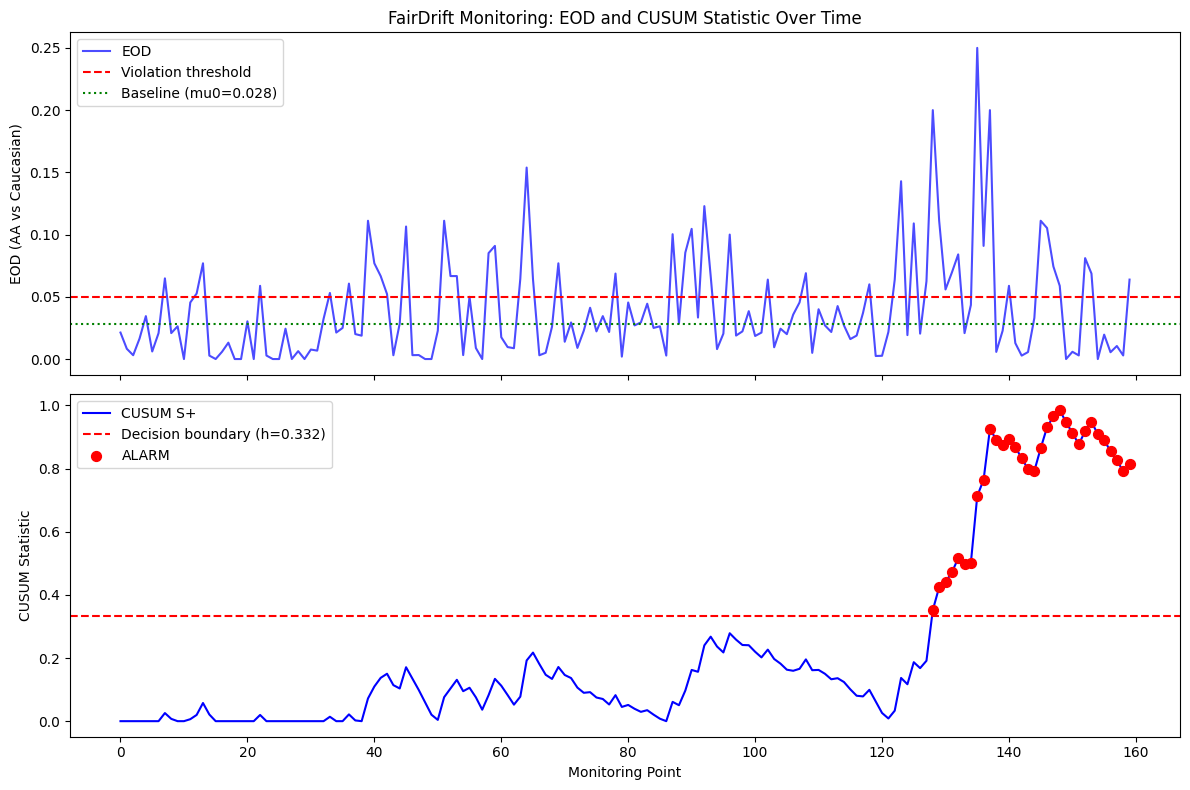

In [5]:
# Figure: CUSUM chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: EOD values over time
ax1.plot(monitor_df['global_point'], monitor_df['eod'], 'b-', alpha=0.7, label='EOD')
ax1.axhline(y=config.EOD_VIOLATION_THRESHOLD, color='red', linestyle='--', label='Violation threshold')
ax1.axhline(y=cusum.mu0, color='green', linestyle=':', label=f'Baseline (mu0={cusum.mu0:.3f})')
ax1.set_ylabel('EOD (AA vs Caucasian)')
ax1.set_title('FairDrift Monitoring: EOD and CUSUM Statistic Over Time')
ax1.legend()

# Bottom: CUSUM statistic
ax2.plot(monitor_df['global_point'], monitor_df['cusum_stat'], 'b-', label='CUSUM S+')
ax2.axhline(y=cusum.h, color='red', linestyle='--', label=f'Decision boundary (h={cusum.h:.3f})')
if monitor_df['alarm'].any():
    alarm_points = monitor_df[monitor_df['alarm']]
    ax2.scatter(alarm_points['global_point'], alarm_points['cusum_stat'], 
                color='red', zorder=5, s=50, label='ALARM')
ax2.set_xlabel('Monitoring Point')
ax2.set_ylabel('CUSUM Statistic')
ax2.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/fig06_cusum_chart.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Save Framework Results

In [6]:
checkpoint_05 = {
    'monitor_df': monitor_df,
    'cusum_params': {
        'mu0': cusum.mu0,
        'k': cusum.k,
        'h': cusum.h,
        'delta': cusum.delta,
    },
    'drift_results': drift_results,
}
with open('../outputs/checkpoint_05.pkl', 'wb') as f:
    pickle.dump(checkpoint_05, f)
print('Saved: checkpoint_05.pkl')

Saved: checkpoint_05.pkl
